In [ ]:
import pandas as pd
from rdkit import Chem

df = pd.read_csv('scaled_output.csv')
df_original = df_original = pd.read_csv('../polygraphpy/data/original_dataset.csv')
df_original = df_original[['smiles', 'mw']]

df = df.merge(df_original, on='smiles')

atoms_number = []

for i in df['smiles'].values:
    mol = Chem.MolFromSmiles(i)
    mol_with_hs = Chem.AddHs(mol)
    num_all_atoms = mol_with_hs.GetNumAtoms()

    atoms_number.append(num_all_atoms)

df['number_of_atoms'] = atoms_number

#df_aux = df[df['mw'] <= 300]
df = df[0.33333 <= df['static_polarizability']*1.20].reset_index(drop=True)
df = df[0.33333 >= df['static_polarizability']*0.80].reset_index(drop=True)
df_aux = df[df['number_of_atoms'] <= 40]
len(df_aux)

KeyError: 'target_scaled'

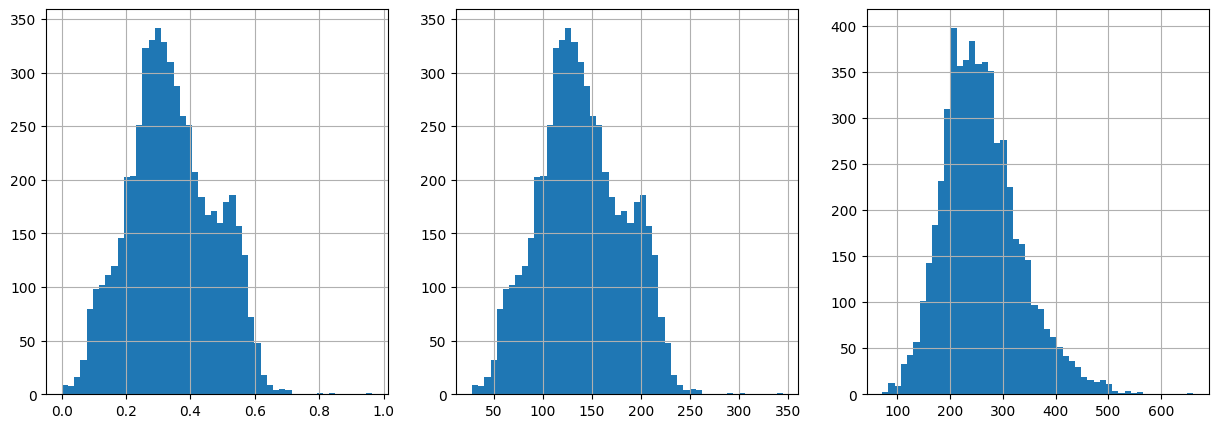

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
df_aux['static_polarizability'].hist(bins=50)

plt.subplot(1,3,2)
df_aux['static_polarizability_original'].hist(bins=50)

plt.subplot(1,3,3)
df_aux['mw'].hist(bins=50)

plt.show()